In [2]:
# ===========================================================
# Conditional GAN (cGAN) untuk Mel-Spectrogram (128x256x1)
# ===========================================================
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from pathlib import Path
import librosa
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses

# --------------- Konfigurasi ---------------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti ke punyamu
SR         = 22050
N_MELS     = 128
N_FFT      = 2048
HOP        = 256
FMIN, FMAX = 20, 8000

# Ukuran kanvas untuk GAN (H, W, C)
IMG_H, IMG_W, IMG_C = 128, 256, 1
LATENT_DIM = 128
BATCH_SIZE = 32
EPOCHS     = 50
SEED       = 42
SAMPLES_OUTDIR = "gan_samples"

np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
os.makedirs(SAMPLES_OUTDIR, exist_ok=True)

# --------------- Util Audio → MelSpec ---------------
def list_audio_files(root, exts=(".wav",".mp3",".flac",".ogg",".m4a",".WAV",".MP3",".FLAC")):
    root = Path(root)
    return [p for p in sorted(root.rglob("*")) if p.suffix in exts and p.is_file()]

def compute_logmel(y, sr):
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0
    )
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)  # (n_mels, T)
    return logS  # range kira2 [-80, 0]

def load_and_melspec(path, duration=None):
    y, sr = librosa.load(path, sr=SR, duration=duration, mono=True)
    if np.max(np.abs(y)) > 0: y = y / np.max(np.abs(y))
    return compute_logmel(y, sr)

def center_pad_or_crop(spec, target_w):
    """spec: (H, T). Tinggi harus IMG_H; T kita pad/crop ke target_w (IMG_W)."""
    H, T = spec.shape
    assert H == IMG_H, f"Mel height {H} != {IMG_H}"
    if T == target_w:
        return spec
    if T < target_w:
        pad_total = target_w - T
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        out = np.pad(spec, ((0,0),(pad_left,pad_right)), mode="constant", constant_values=spec.min())
        return out
    # crop tengah
    start = max(0, (T - target_w)//2)
    return spec[:, start:start+target_w]

def normalize_to_tanh(x):
    """Masuk: log-mel ~ [-80, 0]. Keluarkan: [-1, 1] untuk tanh."""
    # skala z-score ringan lalu ke [-1,1]
    mu, sd = np.mean(x), np.std(x) + 1e-6
    z = (x - mu) / sd
    # compress ke [-1,1] via tanh-friendly scaling
    z = np.tanh(z / 2.0)
    return z

# --------------- Siapkan Dataset ---------------
def load_dataset_from_dir(data_dir):
    root = Path(data_dir)
    class_names = sorted([d.name for d in root.iterdir() if d.is_dir()])
    X, y, paths = [], [], []
    for ci, cname in enumerate(class_names):
        files = list_audio_files(root / cname)
        print(f"[{cname}] {len(files)} file")
        for f in files:
            try:
                mel = load_and_melspec(str(f))
                mel = center_pad_or_crop(mel, IMG_W)         # (128, 256)
                mel = normalize_to_tanh(mel)                 # [-1,1]
                X.append(mel[..., None])                     # (H,W,1)
                y.append(ci); paths.append(str(f))
            except Exception as e:
                print("Gagal:", f, e)
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y, class_names, np.array(paths)

X, y, class_names, paths = load_dataset_from_dir(DATA_DIR)
num_classes = len(class_names)
print("Dataset:", X.shape, "classes:", num_classes, class_names)

# --------------- tf.data pipeline ---------------
def make_dataset(X, y, batch=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X, y, BATCH_SIZE, shuffle=True)

# --------------- Bangun cGAN (Generator & Discriminator) ---------------
# Label embedding helper (untuk conditional)
def label_embedding_block(labels, out_hw):
    """labels: (B,) int → (B, H, W, 1) sebagai peta label"""
    emb_dim = 32
    emb = layers.Embedding(input_dim=num_classes, output_dim=emb_dim)(labels)  # (B, emb_dim)
    # proyeksikan ke (H*W)
    proj = layers.Dense(out_hw[0] * out_hw[1], activation="linear")(emb)       # (B, H*W)
    proj = layers.Reshape((out_hw[0], out_hw[1], 1))(proj)                     # (B,H,W,1)
    return proj

def build_generator(latent_dim=LATENT_DIM):
    z_in   = layers.Input(shape=(latent_dim,), name="z")
    y_in   = layers.Input(shape=(), dtype="int32", name="y")

    # seed 8x8
    x = layers.Dense(8*8*256, use_bias=False)(z_in)
    x = layers.Reshape((8, 8, 256))(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # 8x8 + label(8x8)
    lab = label_embedding_block(y_in, (8, 8))
    x = layers.Concatenate()([x, lab])

    # -> 16x16
    x = layers.Conv2DTranspose(256, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # 16x16 + label(16x16)
    lab = label_embedding_block(y_in, (16, 16))
    x = layers.Concatenate()([x, lab])

    # -> 32x32
    x = layers.Conv2DTranspose(192, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # 32x32 + label(32x32)
    lab = label_embedding_block(y_in, (32, 32))
    x = layers.Concatenate()([x, lab])

    # -> 64x64
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # 64x64 + label(64x64)
    lab = label_embedding_block(y_in, (64, 64))
    x = layers.Concatenate()([x, lab])

    # -> 128x128
    x = layers.Conv2DTranspose(96, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # 128x128 + label(128x128)  ← (INI YANG SALAH DI VERSI LAMA)
    lab = label_embedding_block(y_in, (128, 128))
    x = layers.Concatenate()([x, lab])

    # -> 128x256 (scale horizontal saja)
    x = layers.Conv2DTranspose(64, (4,4), strides=(1,2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # (opsional) tambah conditioning lagi di resolusi akhir:
    # lab = label_embedding_block(y_in, (128, 256))
    # x = layers.Concatenate()([x, lab])

    out = layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh")(x)
    out = layers.Reshape((IMG_H, IMG_W, 1))(out)  # 128x256x1
    return models.Model([z_in, y_in], out, name="Generator")


def build_discriminator():
    x_in = layers.Input(shape=(IMG_H, IMG_W, IMG_C), name="img")
    y_in = layers.Input(shape=(), dtype="int32", name="y")
    # label map (H,W,1)
    lab = label_embedding_block(y_in, (IMG_H, IMG_W))
    x = layers.Concatenate()([x_in, lab])   # (H,W,2)

    def dblock(x, f, s=(2,2), dp=0.3):
        x = layers.Conv2D(f, 4, strides=s, padding="same")(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(dp)(x)
        return x

    x = dblock(x, 64)
    x = dblock(x, 128)
    x = dblock(x, 192)
    x = dblock(x, 256)
    x = layers.Conv2D(256, 3, padding="same")(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128)(x); x = layers.LeakyReLU(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)   # probability real/fake
    return models.Model([x_in, y_in], out, name="Discriminator")

G = build_generator(LATENT_DIM)
D = build_discriminator()
G.summary(); D.summary()

# --------------- cGAN model (custom train_step) ---------------
class ConditionalGAN(tf.keras.Model):
    def __init__(self, generator, discriminator, latent_dim, num_classes):
        super().__init__()
        self.G = generator
        self.D = discriminator
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.d_loss_tracker = tf.keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = tf.keras.metrics.Mean(name="g_loss")

    def compile(self, g_opt, d_opt, d_loss_fn, g_loss_fn):
        super().compile(run_eagerly=False)
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.d_loss_fn = d_loss_fn
        self.g_loss_fn = g_loss_fn

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def train_step(self, data):
        real_imgs, labels = data   # (B,H,W,1), (B,)
        batch_size = tf.shape(real_imgs)[0]

        # ====== Train Discriminator ======
        random_latent = tf.random.normal(shape=(batch_size, self.latent_dim))
        fake_imgs = self.G([random_latent, labels], training=True)

        # real labels = 1, fake = 0 (bisa pakai label smoothing kecil)
        real_y = tf.ones((batch_size, 1))
        fake_y = tf.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            pred_real = self.D([real_imgs, labels], training=True)
            pred_fake = self.D([fake_imgs, labels], training=True)
            d_loss_real = self.d_loss_fn(real_y, pred_real)
            d_loss_fake = self.d_loss_fn(fake_y, pred_fake)
            d_loss = (d_loss_real + d_loss_fake) / 2.0
        grads = tape.gradient(d_loss, self.D.trainable_variables)
        self.d_opt.apply_gradients(zip(grads, self.D.trainable_variables))

        # ====== Train Generator ======
        random_latent = tf.random.normal(shape=(batch_size, self.latent_dim))
        # conditioning dengan label acak (boleh sama dengan labels agar lebih stabil)
        gen_labels = labels
        with tf.GradientTape() as tape:
            gen_imgs = self.G([random_latent, gen_labels], training=True)
            pred = self.D([gen_imgs, gen_labels], training=True)
            g_loss = self.g_loss_fn(tf.ones((batch_size, 1)), pred)  # ingin menipu D → label 1
        grads = tape.gradient(g_loss, self.G.trainable_variables)
        self.g_opt.apply_gradients(zip(grads, self.G.trainable_variables))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}

# --------------- Compile & Train ---------------
gan = ConditionalGAN(G, D, LATENT_DIM, num_classes)
g_opt = optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.999)
d_opt = optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.999)
bce = losses.BinaryCrossentropy(from_logits=False)

gan.compile(g_opt=g_opt, d_opt=d_opt, d_loss_fn=bce, g_loss_fn=bce)

# Callback untuk menyimpan sampel per epoch
class SampleCallback(tf.keras.callbacks.Callback):
    def __init__(self, class_names, n_per_class=4):
        super().__init__()
        self.class_names = class_names
        self.npc = n_per_class

    def on_epoch_end(self, epoch, logs=None):
        r = []
        for ci, cname in enumerate(self.class_names):
            z = tf.random.normal((self.npc, LATENT_DIM))
            lbl = tf.constant([ci]*self.npc, dtype=tf.int32)
            imgs = self.model.G([z, lbl], training=False).numpy()  # [-1,1]
            imgs = (imgs * 127.5 + 127.5).clip(0,255).astype(np.uint8)  # ke [0,255]
            # gabungkan horizontal
            strip = np.concatenate([imgs[i,...,0] for i in range(self.npc)], axis=1)
            r.append(strip)
        grid = np.concatenate(r, axis=0)  # tiap kelas satu baris
        plt.figure(figsize=(12, 6))
        plt.imshow(grid, cmap="magma", aspect="auto")
        plt.axis("off"); plt.tight_layout()
        out = os.path.join(SAMPLES_OUTDIR, f"epoch_{epoch+1:03d}.png")
        plt.savefig(out, dpi=150); plt.close()

sample_cb = SampleCallback(class_names, n_per_class=4)

history = gan.fit(
    train_ds,
    epochs=EPOCHS,
    callbacks=[sample_cb],
    verbose=1
)

# --------------- Generate batch sintetis (augmentasi) ---------------
def synthesize_per_class(generator, n_per_class=50):
    gen_imgs, gen_labels = [], []
    for ci in range(num_classes):
        z = tf.random.normal((n_per_class, LATENT_DIM))
        lbl = tf.constant([ci]*n_per_class, dtype=tf.int32)
        imgs = generator([z, lbl], training=False).numpy()  # [-1,1]
        gen_imgs.append(imgs)
        gen_labels.append(np.full((n_per_class,), ci, dtype=np.int64))
    gen_imgs = np.concatenate(gen_imgs, axis=0)
    gen_labels = np.concatenate(gen_labels, axis=0)
    return gen_imgs, gen_labels

# Contoh penggunaan setelah training:
# synth_X, synth_y = synthesize_per_class(G, n_per_class=100)
# -> ‘synth_X’ berukuran (num_classes*100, 128, 256, 1) dalam skala [-1,1]
# Jika ingin dipakai ke classifier, ubah ke z-score/normalisasi yang sama dengan pipeline classifiermu.


[audioanjing] 37 file
[audiobabi] 24 file
[audiobajingan] 41 file
Dataset: (102, 128, 256, 1) classes: 3 ['audioanjing', 'audiobabi', 'audiobajingan']


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z (InputLayer)                │ (None, 128)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 16384)             │       2,097,152 │ z[0][0]                    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ y (InputLayer)                │ (None)                    │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_6 (Reshape)           │ (None, 8, 8, 256)         │               0 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_5 (Embedding)       │ (None, 32)                │              96 │ y[0][0]                    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 8, 8, 256)         │           1,024 │ reshape_6[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 64)                │           2,112 │ embedding_5[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU)     │ (None, 8, 8, 256)         │               0 │ batch_normalization_5[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_7 (Reshape)           │ (None, 8, 8, 1)           │               0 │ dense_7[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_5 (Concatenate)   │ (None, 8, 8, 257)         │               0 │ leaky_re_lu_5[0][0],       │
│                               │                           │                 │ reshape_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_4            │ (None, 16, 16, 256)       │       1,052,672 │ concatenate_5[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_6 (Embedding)       │ (None, 32)                │              96 │ y[0][0]                    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 16, 16, 256)       │           1,024 │ conv2d_transpose_4[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 256)               │           8,448 │ embedding_6[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU)     │ (None, 16, 16, 256)       │               0 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 5,357,281 (20.44 MB)

 Trainable params: 5,355,297 (20.43 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ y (InputLayer)                │ (None)                    │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_10 (Embedding)      │ (None, 32)                │              96 │ y[0][0]                    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_12 (Dense)              │ (None, 32768)             │       1,081,344 │ embedding_10[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ img (InputLayer)              │ (None, 128, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_13 (Reshape)          │ (None, 128, 256, 1)       │               0 │ dense_12[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_10 (Concatenate)  │ (None, 128, 256, 2)       │               0 │ img[0][0],                 │
│                               │                           │                 │ reshape_13[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 64, 128, 64)       │           2,112 │ concatenate_10[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_11 (LeakyReLU)    │ (None, 64, 128, 64)       │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64, 128, 64)       │               0 │ leaky_re_lu_11[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 32, 64, 128)       │         131,200 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_12 (LeakyReLU)    │ (None, 32, 64, 128)       │               0 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 32, 64, 128)       │               0 │ leaky_re_lu_12[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 16, 32, 192)       │         393,408 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_13 (LeakyReLU)    │ (None, 16, 32, 192)       │               0 │ conv2d_3[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 16, 32, 192)       │               0 │ leaky_re_lu_13[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 8, 16, 256)        │         786,688 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_14 (LeakyReLU)    │ (None, 8, 16, 256)        │               

 Total params: 7,179,489 (27.39 MB)

 Trainable params: 7,179,489 (27.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 99s 27s/step - d_loss: 0.6590 - g_loss: 1.1679
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 27s/step - d_loss: 0.3452 - g_loss: 5.5439
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 86s 29s/step - d_loss: 0.1895 - g_loss: 7.2050
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 27s/step - d_loss: 0.0884 - g_loss: 6.1737
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 79s 27s/step - d_loss: 0.0280 - g_loss: 7.0231
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 28s/step - d_loss: 0.0318 - g_loss: 10.9174
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 28s/step - d_loss: 0.6270 - g_loss: 17.4368
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 27s/step - d_loss: 0.1290 - g_loss: 8.8437
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 27s/step - d_loss: 0.0033 - g_loss: 7.0852
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - d_loss: 0.0059 - g_loss: 5.7794
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - d_loss: 0.9449 - g_loss: 8.3241
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - d_loss: 0.4403 - g_los

Confusion matrix (synthetic → predicted):
 [[37 13  0]
 [32 18  0]
 [42  8  0]]

Classification report (synthetic):
               precision    recall  f1-score   support

  audioanjing     0.3333    0.7400    0.4596        50
    audiobabi     0.4615    0.3600    0.4045        50
audiobajingan     0.0000    0.0000    0.0000        50

     accuracy                         0.3667       150
    macro avg     0.2650    0.3667    0.2880       150
 weighted avg     0.2650    0.3667    0.2880       150



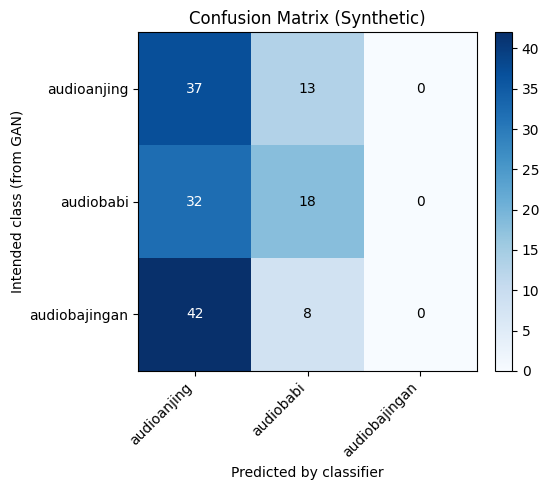

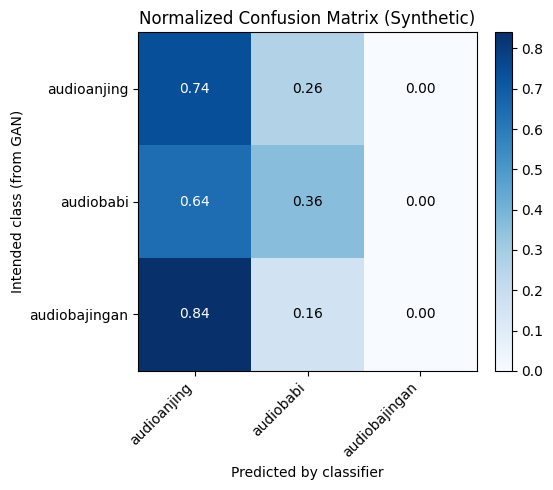

In [7]:
# ============================
# Confusion Matrix untuk sampel GAN dengan classifier tersimpan
# ============================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# --- Custom layer (kalau classifier kamu memakainya di arsitektur) ---
class SpecAugment(layers.Layer):
    def __init__(self, time_mask=0.08, freq_mask=0.08, **kwargs):
        super().__init__(**kwargs); self.time_mask=float(time_mask); self.freq_mask=float(freq_mask)
    def get_config(self):
        cfg = super().get_config(); cfg.update({"time_mask": self.time_mask, "freq_mask": self.freq_mask}); return cfg
    def compute_output_shape(self, input_shape): return input_shape
    def _mask_one(self, sample):
        H = tf.shape(sample)[0]; W = tf.shape(sample)[1]; C = tf.shape(sample)[2]
        t_w = tf.maximum(1, tf.cast(tf.round(self.time_mask * tf.cast(W, tf.float32)), tf.int32))
        f_w = tf.maximum(1, tf.cast(tf.round(self.freq_mask * tf.cast(H, tf.float32)), tf.int32))
        t0 = tf.cond(W > t_w, lambda: tf.random.uniform([], 0, W - t_w + 1, dtype=tf.int32), lambda: 0)
        f0 = tf.cond(H > f_w, lambda: tf.random.uniform([], 0, H - f_w + 1, dtype=tf.int32), lambda: 0)
        cols = tf.range(W)[tf.newaxis, :, tf.newaxis]; rows = tf.range(H)[:, tf.newaxis, tf.newaxis]
        time_band = tf.logical_and(cols >= t0, cols < t0 + t_w); freq_band = tf.logical_and(rows >= f0, rows < f0 + f_w)
        time_mask = tf.cast(tf.logical_not(time_band), sample.dtype); time_mask = tf.tile(time_mask, [H, 1, C])
        freq_mask = tf.cast(tf.logical_not(freq_band), sample.dtype); freq_mask = tf.tile(freq_mask, [1, W, C])
        return sample * (time_mask * freq_mask)
    def call(self, x, training=False):
        if not training or (self.time_mask <= 0 and self.freq_mask <= 0): return x
        return tf.map_fn(self._mask_one, x)

# --- 1) Load classifier TANPA compile (hindari error loss kustom) ---
CLASSIFIER_PATH = "best_cnn_melspec.keras"  # ganti jika beda
model = load_model(
    CLASSIFIER_PATH,
    custom_objects={"SpecAugment": SpecAugment},  # loss tidak diperlukan untuk predict
    compile=False
)
# (opsional) jika ingin compile ulang untuk evaluasi lain:
# model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# --- 2) Helper untuk generate sampel sintetis dari GAN ---
def synthesize_per_class(generator, num_classes, latent_dim, n_per_class=50):
    gen_imgs, gen_labels = [], []
    for ci in range(num_classes):
        z = tf.random.normal((n_per_class, latent_dim))
        lbl = tf.constant([ci]*n_per_class, dtype=tf.int32)
        imgs = generator([z, lbl], training=False).numpy()  # [-1,1], (N,H,W,1)
        gen_imgs.append(imgs)
        gen_labels.append(np.full((n_per_class,), ci, dtype=np.int64))
    return np.concatenate(gen_imgs,0), np.concatenate(gen_labels,0)

# --- 3) Samakan format input dengan classifier ---
def per_sample_zscore(x):
    x = x.copy()
    for i in range(x.shape[0]):
        mu = x[i].mean(); sd = x[i].std() + 1e-6
        x[i] = (x[i] - mu) / sd
    return x

def ensure_model_input(X, model):
    # model.input_shape: (None, Hm, Wm, Cm)
    _, Hm, Wm, Cm = model.input_shape
    X2 = X
    # resize bila perlu
    if (X2.shape[1] != Hm) or (X2.shape[2] != Wm):
        X2 = tf.image.resize(X2, (Hm, Wm), method="bilinear").numpy()
    # tile channel bila classifier butuh C>1
    if X2.shape[-1] != Cm:
        X2 = np.repeat(X2, Cm, axis=-1)
    return X2

# --- 4) Generate, normalisasi, prediksi, lalu confusion matrix ---
# Pastikan variabel ini sudah ada dari sesi GAN kamu:
# G (generator terlatih), num_classes, class_names, LATENT_DIM
N_PER_CLASS = 50  # ubah sesuai kebutuhan
X_synth, y_intended = synthesize_per_class(G, num_classes, LATENT_DIM, n_per_class=N_PER_CLASS)

# normalisasi per-sample agar konsisten dengan pipeline classifier
X_synth = per_sample_zscore(X_synth)
# sesuaikan dengan input classifier
X_synth = ensure_model_input(X_synth, model)

# prediksi
y_prob = model.predict(X_synth, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# confusion matrix & report
cm = confusion_matrix(y_intended, y_pred, labels=np.arange(num_classes))
print("Confusion matrix (synthetic → predicted):\n", cm)
try:
    print("\nClassification report (synthetic):")
    print(classification_report(y_intended, y_pred, target_names=class_names, digits=4))
except Exception:
    print(classification_report(y_intended, y_pred, digits=4))

# visualisasi
def plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap=plt.cm.Blues, interpolation="nearest")
    plt.title(title); plt.colorbar(fraction=0.046, pad=0.04)
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i,j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("Intended class (from GAN)")
    plt.xlabel("Predicted by classifier")
    plt.tight_layout(); plt.show()

plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix (Synthetic)")
plot_confusion_matrix(cm, class_names, normalize=True,  title="Normalized Confusion Matrix (Synthetic)")
